<img src="images/logo/selene-logo-640.png" style="max-height:75px;" alt="SELENE Logo" />

**Disclaimer:** This Jupyter Notebook contains content generated with the assistance of AI. While every effort has been made to review and validate the outputs, users should independently verify critical information before relying on it. The SELENE notebook repository is constantly evolving. We recommend downloading or pulling the latest version of this notebook from Github.

# The Adam Optimizer

Training modern neural networks requires optimization algorithms that can efficiently navigate high-dimensional, noisy, and often ill-conditioned loss landscapes. While basic gradient descent provides the foundation, its limitations quickly become apparent in practice, ranging from slow convergence to unstable updates. Over time, more advanced optimizers have been developed to address these challenges, including momentum-based methods and adaptive learning rate techniques. Among these, the Adam optimizer has emerged as one of the most popular and widely used choices for training large-scale neural networks.

Adam builds directly on two key ideas introduced in earlier optimizers: exponentially weighted moving average (EWMA) momentum and RMSProp. Momentum methods improve optimization by smoothing updates and maintaining consistent movement in directions where gradients agree, while RMSProp adapts learning rates on a per-parameter basis using recent gradient magnitudes. Adam combines these strengths into a single algorithm, leveraging both directional information and adaptive scaling to produce updates that are both stable and efficient across a wide range of problems.

This notebook takes a hands-on approach to understanding these concepts. Rather than treating Adam as a black box, it begins by implementing EWMA momentum and RMSProp from scratch, building intuition for how each method behaves individually. By grounding the discussion in concrete implementations, the notebook provides a clear pathway from these foundational ideas to the full Adam algorithm.

To deepen this understanding, the notebook directly compares the update behavior of all three optimizers on a shared example function. This side-by-side analysis highlights how momentum, RMSProp, and Adam differ in terms of stability, scaling, and convergence dynamics. Through this practical exploration, the notebook aims to provide not only a conceptual understanding of Adam, but also an intuition for why it has become a default choice in modern deep learning workflows.

### Setting up the Notebook

#### Make Required Imports

This notebook requires the import of different Python packages but also additional Python modules that are part of the repository. If a package is missing, use your preferred package manager (e.g., [conda](https://anaconda.org/anaconda/conda) or [pip](https://pypi.org/project/pip/)) to install it. If the code cell below runs with any errors, all required packages and modules have successfully been imported.

In [1]:
import numpy as np

from src.utils.plotting.gd import *

#### Preliminaries

* This notebook assumes a basic understanding of calculus and concepts of derivatives and partial derivatives.
* Although the notebook starts with a brief recap about EWMA momentum and RMSProp, being already familiar with both algorithms is recommended.

---

## Quick Recap: Related Optimizers

In the following, we therefore provide a recap about EWMA Momentum and RMSProp to highlight their respective strengths and weaknesses which then will help us to better understand the idea behind Adam. To illustrate their differences, we will implement all three optimizers to observe their behavior. Throughout this notebook we consider a multivariate function $f$ together with its derivative $g=f^\prime$ as a concrete example as defined below; we limit ourselves to only two inputs here to ease visualization, but all concepts apply to an arbitrary number of inputs.

$$
\begin{align}
\large f(x_1, x_2)\ &\large = 0.1x_1^2 + 5x_2^2\\[0.5em]
\large g(x_1, x_2)\ &\large = 0.2x_1 + 10x_2
\end{align}
$$

We also implement both functions as Python methods for testing all optimizer algorithms and visualize their results.

In [2]:
def f(x1, x2):
    return 0.1*(x1**2) + 5*(x2**2)

def g(x1, x2):
    return 0.2*x1, 10*x2

Before going further, let's first have a look at the function, using the provided auxiliary method `plot_multivariate_function(f)`.

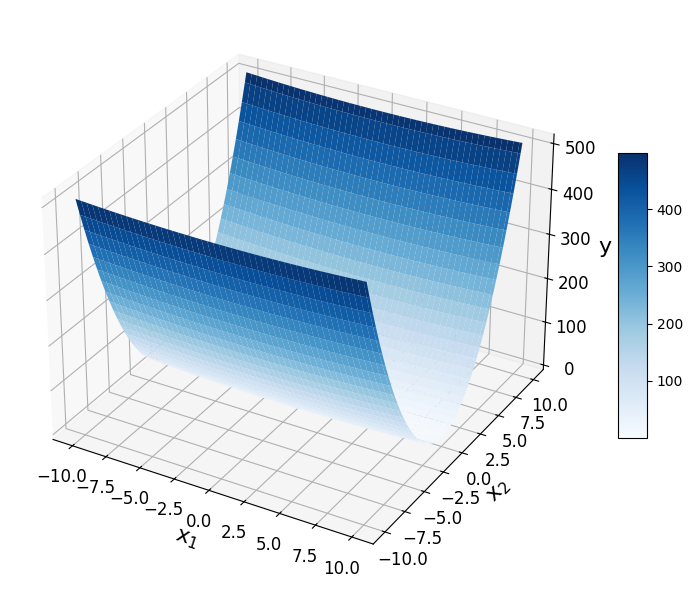

In [3]:
plot_multivariate_function(f)

Although we already know just from looking at the function $f$ that its minimum is at $x_1 = x_2 = 0$, this is not very obvious from the plot. The issues here is that function $f$, despite its simplicity, can be considered **ill-conditioned**. This means that small changes in its input or in the optimization process can lead to large and unstable changes in the output or in the path toward the minimum. In the context of optimization, this typically means that the function's curvature differs significantly across dimensions: in some directions the function changes very steeply, while in others it is relatively flat. Even for simple functions (e.g., quadratic forms), this can produce elongated, narrow valleys where the minimum lies, making it difficult for optimization algorithms to move efficiently toward the optimum.

To this function $f$, we will apply all three optimizers to find its minimum. For a fair comparison, we will be using the same initial choice of the parameters set at $x_1 = 9$ and $x_2 = -3$.

In [4]:
x0 = np.asarray([9, -3])

With the basic optimization task in place, let's briefly recap how EWMA momentum and RMSProp works.

### EWMA Momentum

Exponentially Weighted Moving Average (EWMA) momentum is an extension of basic Gradient Descent that smooths parameter updates by incorporating a running average of past gradients. Instead of updating parameters solely based on the current gradient, EWMA maintains a "velocity" term $\mathbf{v}$ &mdash; an exponentially decaying average of previous gradients &mdash; so that recent gradients have more influence while older ones gradually fade. This velocity is then used to update the parameters, effectively introducing memory into the optimization process. Mathematically, EWMA momentum is defined as:

$$
\begin{align}
\large \mathbf{v}^{(t+1)}\ &\large = \beta\mathbf{v}^{(t)} + (1-\beta)g^{(t)}\\[0.5em]
\large \mathbf{\hat{v}}^{(t+1)}\ &\large = \frac{\mathbf{v}^{(t+1)}}{1 - \beta^t}\\[0.5em]
\large \mathbf{x}^{(t+1)}\ &\large = \mathbf{x}^{(t)} - \eta\cdot \mathbf{v}^{(t+1)}
\end{align}
$$

The hyperparameter  $\beta \in [0,1]$ (also sometimes called the momentum coefficient) controls how much of the past velocity is carried over to the current update. Its value is typically chosen in the range 0.5 to 0.99, with 0.9 a common default value, depending on the problem and the desired behavior. Lastly, $\eta$ denotes the learning rate, i.e., the scaling factor to (typically) scale down the gradients before the parameter update, just like in basic Gradient Descent. $\mathbf{\hat{v}}^{(t)}$ is the so-called bias correction term which is commonly applied. This addresses the consideration that we typically initialize $\mathbf{v}^{(0)} = \mathbf{0}$, meaning that in the early iterations the accumulated value is biased toward zero rather than reflecting the true scale of the gradients.

The core intuition is that basic Gradient Descent can be slow and unstable, especially in regions where the loss surface is noisy or ill-conditioned (e.g., steep in one direction and flat in another). EWMA momentum helps by dampening oscillations in directions where gradients frequently change sign, while accelerating progress in directions with consistent gradients. As a result, it leads to smoother, faster convergence and reduces the zig-zagging behavior often observed with plain Gradient Descent.

The method `ewma()` in the code cell below implements EWMA momentum. Note that the method returns the history of all parameter updates. While this is usually not required in practice, we can use this history to later plot the path the updates describe across the surface of the function.

In [5]:
def sgd_ewma(g, x, beta, eta, n_steps):
    # Initialize history of x values
    xs = [x]
    v = np.zeros_like(x)
    # Run basic Gradient Descent for n_steps iterations
    for t in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x))
        # Update the velocity vector v
        v = beta*v + (1-beta)*gradient
        # Bias correction
        v_corrected = v / (1 - beta**(t+1))
        # Update x values based on gradient and learning rate
        x = x - eta*v_corrected
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

Let's run method `ewma()` to find the minimum of our example function for some default values for the hyperparameters, i.e., the momentum coefficient $\beta$, the learning rate $\eta$, and the total number of iterations we want to perform. Of course, you can change the hyperparameters to see how different values affect the final results.

In [6]:
beta, eta, n_steps = 0.9, 0.1, 100

xs_ewma = sgd_ewma(g, x0, beta, eta, n_steps)

`xs_ewma` contains all the parameter updates, which we can now pass to the auxiliary method `plot_gradient_descent_2d` to plot the path. Apart from the update history, the method also receives `f` to visualize the 2d function as contour plot, and `eta` for setting the title of the plot. Just run the code cell below to generate the animated plot (note that this might take a few seconds).

In [7]:
plot_gradient_descent_2d(f, xs_ewma, eta=eta, title=f"EWMA Momentum (η = {eta})")

As the plot shows, a key limitation of EWMA momentum is that the velocity term can become "too persistent", especially on ill-conditioned loss surfaces where curvature differs strongly across directions. Because the velocity is an exponentially averaged sum of past gradients, it does not immediately reflect sudden changes in the gradient direction. As a result, when the optimizer enters a region where the optimal direction shifts (e.g., near a narrow valley or steep curvature change), the accumulated momentum can keep pushing the parameters forward, causing overshooting or oscillations.

This happens because the EWMA update trades responsiveness for smoothness: it filters noise but also slows down adaptation. In ill-conditioned settings, where careful, direction-specific adjustments are required, this lag in adapting the velocity vector can lead to inefficient updates and instability, motivating more advanced methods that better balance memory and adaptivity. This is where RMSProp comes in.

### RMSProp

RMSProp is an adaptive optimization algorithm designed to fix the main weakness of AdaGrad; see the separate notebook covering AdaGrad. In a nutshell, AdaGrad keeps a running sum of all past squared gradients, and uses this sum to scale learning rate on a per-parameter basis, which causes the effective learning rate to shrink continuously over time. In long training runs, this can make parameter updates become extremely small and slow down learning too much.

RMSProp solves this by replacing the cumulative sum with an exponentially weighted moving average of recent squared gradients &mdash; just like EWMA momentum but only for the *magnitude* of the gradients but not the *direction* of the gradients. Thus,  instead of remembering all past gradients equally, it mainly focuses on the most recent ones. Parameters whose gradients are consistently large receive smaller updates, while parameters with small or infrequent gradients receive relatively larger updates. This gives each parameter its own adaptive learning rate and helps the optimizer make steady progress even on difficult, uneven loss surfaces often encountered in neural network training. Mathematically, all updates steps of RMSProps are defined as:

$$
\begin{align}
\large \mathbf{v}^{(t+1)}\ &\large = \beta\mathbf{v}^{(t)} + (1-\beta)\left[ g^{(t)} \right]^2\\[0.5em]
\large \mathbf{x}^{(t+1)}\ &\large = \mathbf{x}^{(t)} - \frac{\eta}{\sqrt{\mathbf{v}^{(t+1)} + \epsilon}}\odot g^{(t)}
\end{align}
$$

Like EWMA momentum, this allows for a straightforward implementation of RMSProp like the method shown in the code cell below.

In [8]:
def rmsprop(g, x, beta, eta, n_steps, epsilon=1e-8):
    # Initialize history of x values
    xs = [x]
    v = np.zeros_like(x)
    # Run basic Gradient Descent for n_steps iterations
    for t in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x))
        # Update the velocity vector v
        v = beta*v + (1-beta)*(gradient**2)
        # Update x values based on gradient and learning rate
        x = x - (eta*gradient / (np.sqrt(v) + epsilon))
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

Using the same values for all hyperparameters (i.e., moment coefficient $\beta$, learning rate $\eta$, and number of iterations), we can use method `rmsprop()` to find the minimum for our example function $f$.

In [9]:
beta, eta, n_steps = 0.9, 0.1, 100

xs_rmsprop = rmsprop(g, x0, beta, eta, n_steps)

Of course, we can use our auxiliary method `plot_gradient_descent_2d()` once again to plot the update history as an animation.

In [10]:
plot_gradient_descent_2d(f, xs_rmsprop, eta=eta, title=f"RMSProp (η = {eta})")

In RMSProp, each parameter's update is scaled by the inverse of the square root of an exponentially weighted average of its recent squared gradients. This means that parameters experiencing consistently large gradients get their updates dampened, while those with smaller gradients can still move meaningfully. As a result, RMSProp naturally reduces the "zig-zagging" (i.e., oscillating) behavior you often see in ill-conditioned problems, leading to smoother and more stable update trajectories across the loss surface.

However, **RMSProp only tracks the magnitude of gradients** (through squared values) and ignores their direction over time. This means it cannot capture whether gradients are consistently pointing in a similar direction or rapidly changing sign. In practice, this can be limiting because directional consistency is valuable information for accelerating convergence, especially in shallow or gently sloped regions. This is where Adam mainly improves upon RMSPRops.

---

## The Adam Algorithm

The Adam optimizer combines two key ideas: **momentum** (via an exponentially weighted moving average of gradients) and **adaptive learning rates** (as in RMSProp, which itself builds on AdaGrad). Specifically, Adam keeps track of both the first moment (the mean of past gradients) to capture direction, and the second moment (the mean of squared gradients) to capture magnitude. These estimates are bias-corrected and then used together to scale parameter updates, so each parameter benefits from both smoother directional movement and adaptive step sizes. This combination allows Adam to make fast, stable progress across a wide range of optimization landscapes. As a result, Adam is often a strong default optimizer in practice, especially for training deep neural networks with complex and noisy loss surfaces.

### Definition & Implementation

With respect to the first key idea, Adam computes **two momentums** using exponentially weighted moving average (EWMA):

* The **first moment**, i.e., the EWMA of the gradients (like the EWMA momentum optimizer) take past gradients into account for the update of the parameters. The EWMA also ensures that more recent gradients influence the update more than early gradients.
* The **second moment**, i.e., the EWMA of the squared gradients (like the RMSProp and AdaGrad optimizer) capture the information about the scale of past gradients to compute adaptive and parameter-specific learning rates. Omitting the mathematical details here, squaring the gradients removes their sign and emphasizes their magnitude, so averaging these squared values over time provides an estimate of how large (and variable) the gradients typically are. This acts as a proxy for the uncentered variance of the gradients, allowing the optimizer to gauge the scale of updates and adjust learning rates accordingly.

These two moments are computed as shown below &mdash; note that both momentums use different momentum coefficients: $\beta_1$ and $\beta_2$, respectively.

$$
\begin{align}
\large \mathbf{m}^{(t)}\ &\large = \beta_1\mathbf{m}^{(t-1)} + (1-\beta_1)g^{(t-1)}\\[0.5em]
\large \mathbf{v}^{(t)}\ &\large = \beta_2\mathbf{v}^{(t-1)} + (1-\beta_2)\left[ g^{(t-1)} \right]^2\\[0.5em]
\end{align}
$$

Since both $\mathbf{\hat{m}}^{(t)}$ and $\mathbf{\hat{v}}^{(t)}$ are initialized with $\mathbf{0}$, we apply a bias correction term to both sums. For more details how this bias term is derived, you can check out the notebook covering various momentum methods for Gradient Descent (incl. EWMA momentum). But again, the intuition is that both sums are likely to underestimate the the two momentums give that we initialize $\mathbf{\hat{m}}^{(t)} = \mathbf{\hat{v}}^{(t)} = \mathbf{0}$.

$$
\begin{align}
\large \mathbf{\hat{m}}^{(t)}\ &\large = \frac{\mathbf{m}^{(t)}}{1 - \beta_1^t}\\[0.5em]
\large \mathbf{\hat{v}}^{(t)}\ &\large = \frac{\mathbf{v}^{(t)}}{1 - \beta_2^t}
\end{align}
$$

The last step is now to perform the parameter update using our two momentums. More specifically, we use the first moment $\mathbf{\hat{m}}^{(t)}$ instead of the current gradient (again, the basic idea behind EWMA momentum), and the second moment $\mathbf{\hat{v}}^{(t)}$ to scale the learning rate for each parameter individually (again, the basic idea behind RMSProp and AdaGrad). Of course, for both momentums, we use the bias-corrected values. This gives us the following formula for the update step of Adam:

$$
\begin{align}
\large \mathbf{x}^{(t)}\ &\large = \mathbf{x}^{(t-1)} - \frac{\eta}{\sqrt{\mathbf{\hat{v}}^{(t-1)} + \epsilon}}\odot \mathbf{\hat{m}}^{(t)}
\end{align}
$$

Implementing the Adam optimizer also comes down to simply combining the implementation of EWMA momentum and RMSProps; see the method `adam()` in the code cell below. The obvious difference here is, of course, that we now have to compute two sums instead of one since we are using the first moment (momentum) and second moment (squared gradients) with respect to the gradients.

In [11]:
def adam(g, x, beta1, beta2, eta, n_steps, epsilon=1e-8):
    # Initialize history of x values
    xs = [x]
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    # Run basic Gradient Descent for n_steps iterations
    for t in range(n_steps):
        # Compute the gradient for current x values using derivative
        gradient = np.asarray(g(*x))
        # Update the velocity vector v
        m = beta1*m + (1-beta1)*(gradient)
        v = beta2*v + (1-beta2)*(gradient**2)
        # Bias correction
        m_corrected = m / (1 - beta1**(t+1))
        v_corrected = v / (1 - beta2**(t+1))
        # Update x values based on gradient and learning rate
        x = x - (eta*m_corrected / (np.sqrt(v_corrected + epsilon)))
        # Add updated x values to history
        xs.append(x)
    # Return history of x values as a NumPy array
    return np.asarray(xs)

Let's use `adam()` to once more find the minimum of our example function $f$. Naturally, we now have to specify two separate momentum coefficients $\beta_1$ and $\beta_2$. Common default values are $\beta_1 = 0.9$ for the first moment (momentum) and $\beta_2 = 0.999$ for the second moment (squared gradients). The intuition is that $\beta_1 = 0.9$ provides a reasonably long but still responsive memory of past gradients, helping smooth noisy updates while still adapting to changes in direction. In contrast, $\beta_2 = 0.999$ uses a much longer memory to stabilize the estimate of gradient magnitudes, since these tend to be more variable and benefit from stronger averaging.

Since Adam now uses the momentum (like EWMA momentum but unlike RMSProp) we need to decrease the learning rate again compared to RMSProp. By default, we use a learning rate of $\eta = 0.2$ but as usual, you can change all hyperparameters to see their effects on the final results.

In [12]:
beta1, beta2, eta, n_steps = 0.9, 0.999, 0.2, 100

xs_adam = adam(g, x0, beta1, beta2, eta, n_steps)

Finally, let's also plot the update history generated by the Adam optimizer as an animated plot.

In [13]:
plot_gradient_descent_2d(f, xs_adam, eta=eta, title=f"Adam (η = {eta})")

Comparing the update history of Adam with the ones of EWMA momentum and RMSProp for the same function, we can roughly see that Adam does indeed combine the behavior of the other two optimizers. The update history still shows some oscillation due using the first moment (momentum), but it is much less pronounced compared to EWMA momentum due to the use of parameter-specific learning rates informed by the second moment (squared gradients). The result is a trajectory that is typically smoother than RMSProp (which can still be somewhat noisy due to lack of directional averaging) and more stable than pure momentum (which can overshoot or oscillate if step sizes are not well-tuned).

### Discussion

The Adam optimizer combines the strengths of momentum and adaptive learning rates, which gives it several key advantages. By maintaining an exponentially weighted average of gradients, it produces smooth, low-noise updates that follow consistent directions, while its second-moment estimate (inherited from ideas in RMSProp) scales each parameter's update according to the magnitude of recent gradients. This leads to stable training, reduced oscillations, and efficient progress even on ill-conditioned or highly non-uniform loss surfaces. Additionally, Adam's bias correction helps ensure reliable behavior early in training, and it typically requires little hyperparameter tuning.

These properties make Adam especially well-suited for large neural networks, where loss landscapes are complex, noisy, and high-dimensional. Its ability to adapt learning rates per parameter and handle sparse or uneven gradients allows it to perform robustly across a wide range of architectures and tasks. Because it "just works" in many settings without extensive manual tuning, Adam has become the de-facto default optimizer in deep learning practice, particularly for training large-scale models where stability and efficiency are critical.

While the Adam optimizer is very effective in practice, it is not a perfect optimization as it is not without drawbacks. The main limitations and practical considerations of the Adam optimizer include:

* **Potentially worse generalization:** Compared to simpler methods like SGD with momentum, Adam can converge to solutions that fit the training data very well but generalize less effectively. This is often attributed to its aggressive, parameter-specific adaptive learning rates, which may prevent the model from settling into flatter minima that are typically associated with better generalization.

* **Sensitive and interacting hyperparameters:** Adam introduces multiple hyperparameters $\beta_1$, $\beta_2$, and the learning rate $\eta$ that interact in non-trivial ways. While default values often work well, suboptimal choices can lead to unstable updates, slow convergence, or poor final performance. This makes debugging and tuning less intuitive compared to simpler optimizers.

* **Imperfect moment estimates:** Adam relies on exponentially weighted moving averages of both gradients and squared gradients. In highly noisy or rapidly changing optimization landscapes, these estimates can become inaccurate or lag behind the true gradient statistics, leading to suboptimal or erratic update behavior, especially early in training or during distribution shifts.

* **Convergence issues in theory and practice:** In certain cases, Adam may fail to converge to the true optimum or exhibit undesirable behavior (e.g., oscillations or divergence). These issues stem from how adaptive learning rates are computed and accumulated over time, and they have motivated research into more robust variants.

Many of the practical limitations of the Adam optimizer are mitigated by combining it with **additional training strategies** rather than relying on it in isolation. A key example is using **learning rate schedules** (e.g., warm-up followed by decay), which help stabilize training early on and encourage better convergence later. Warm-up reduces the risk of unstable updates when Adam's moment estimates are still inaccurate, while decay (such as cosine or step decay) helps the optimizer settle into better minima, often improving generalization.

Beyond scheduling, several other techniques are commonly used. For instance, decoupled weight decay as implemented in **AdamW** optimizer improves regularization behavior. **Gradient clipping** is often applied to prevent extreme updates in the presence of large gradients, especially in deep or recurrent networks. Additionally, practitioners sometimes **switch optimizers during training** (e.g., starting with Adam for fast progress and finishing with SGD for better generalization), or tune batch sizes and normalization techniques (like batch normalization) to stabilize gradient statistics. Together, these methods help compensate for Adam's weaknesses and make it far more robust in real-world large-scale training.

---

## Summary

This notebook introduced the Adam optimizer by first revisiting two of its core building blocks: exponentially weighted moving average (EWMA) momentum and RMSProp. The recap provided both the intuition and a NumPy-based implementation of these methods, highlighting how momentum smooths updates by incorporating past gradient directions, while RMSProp adapts learning rates based on the magnitude of recent gradients. Together, these techniques address key limitations of basic gradient descent and form the conceptual foundation of Adam.

Building on this, the notebook implemented Adam itself, showing how it combines first-moment estimates (momentum) and second-moment estimates (adaptive scaling) into a single update rule. Particular attention was given to how these components interact, including the role of bias correction in stabilizing early training. By grounding the implementation in the previously introduced methods, the notebook made it clear how Adam naturally emerges as a unification of these ideas rather than an entirely separate concept.

A central part of the notebook was the direct comparison between EWMA momentum, RMSProp, and Adam. By applying all three optimizers to the same example function, it became possible to observe their differing update behaviors in practice. Momentum demonstrated smooth but sometimes poorly scaled updates, RMSProp showed well-scaled but potentially noisy updates, and Adam combined both advantages: producing updates that were both stable and well-adapted to the geometry of the problem.

In conclusion, Adam stands out as one of the most widely used optimizers for training modern neural networks, particularly in large-scale and complex settings. Its ability to balance stability, speed, and adaptability makes it a strong default choice in many applications. For this reason, developing a solid understanding of Adam &mdash; both its underlying components and its practical behavior &mdash; is essential for anyone working with deep learning models.